# 03. Model Coxa i diagnostyka semiparametryczna

            Notebook odtwarza model Coxa, test proporcjonalności hazardów, reszty Schoenfelda, wariant z efektem zależnym od czasu, obserwacje wpływowe oraz predykcje przeżycia dla profili pacjentów.


## Import bibliotek i przygotowanie danych


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

# UWAGA:
# Plik z danymi powinien znajdować się najlepiej w tym samym folderze co notebook
# albo w podfolderze "data".
#
# Oczekiwana nazwa pliku:
# heart_failure_clinical_records_dataset.csv
#
# Kod nie używa bezwzględnych ścieżek Windows, dzięki czemu notebook powinien
# działać po przeniesieniu do dowolnego katalogu roboczego.

DATA_FILENAME = "heart_failure_clinical_records_dataset.csv"


def find_data_file(filename: str = DATA_FILENAME) -> Path:
    """
    Szuka pliku danych w typowych lokalizacjach względem katalogu roboczego
    i jego katalogów nadrzędnych.

    Priorytet:
    1. bieżący katalog roboczy,
    2. podfolder data,
    3. podfolder Data,
    4. katalogi nadrzędne,
    5. rekurencyjne wyszukiwanie w bieżącym katalogu i katalogach nadrzędnych.
    """
    cwd = Path.cwd().resolve()
    search_roots = [cwd, *cwd.parents]

    direct_candidates = []
    for root in search_roots:
        direct_candidates.extend([
            root / filename,
            root / "data" / filename,
            root / "Data" / filename,
        ])

    for candidate in direct_candidates:
        if candidate.exists():
            return candidate.resolve()

    for root in search_roots:
        matches = list(root.rglob(filename))
        if matches:
            return matches[0].resolve()

    raise FileNotFoundError(
        f"Nie znaleziono pliku danych: {filename}\n"
        "Umieść plik w tym samym folderze co notebook albo w podfolderze 'data'."
    )


DATA_PATH = find_data_file()

print(f"Wczytywany plik danych: {DATA_PATH}")

df = pd.read_csv(DATA_PATH).drop_duplicates().copy()

df["duration"] = df["time"].astype(float)
df["event"] = df["DEATH_EVENT"].astype(int)

df["age_60plus"] = (df["age"] >= 60).astype(int)
df["ef_low"] = (df["ejection_fraction"] < 35).astype(int)
df["creatinine_high"] = (df["serum_creatinine"] > 1.5).astype(int)
df["sodium_low"] = (df["serum_sodium"] < 135).astype(int)

df["log_cpk"] = np.log1p(df["creatinine_phosphokinase"])
df["log_platelets"] = np.log(df["platelets"])


def show(title, obj):
    print(f"\n{title}")
    print("-" * len(title))
    if isinstance(obj, pd.DataFrame):
        print(obj.to_string())
    elif isinstance(obj, pd.Series):
        print(obj.to_string())
    else:
        print(obj)


from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
from scipy.stats import chi2

cox_vars = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium",
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking",
    "log_cpk",
]

cox_df = df[["duration", "event"] + cox_vars].copy()

show("Zmiennie modelu Coxa", pd.Series(cox_vars))

Wczytywany plik danych: C:\Users\jakob\OneDrive\Pulpit\A_MAGISTERKA SGH\Analiza_czasu_trwania\PROJECT\ACT\Workspace\WERSJA_POPRAWIONA\jupyter_notebooks\heart_failure_clinical_records_dataset.csv

Zmiennie modelu Coxa
--------------------
0                    age
1      ejection_fraction
2       serum_creatinine
3           serum_sodium
4                anaemia
5               diabetes
6    high_blood_pressure
7                    sex
8                smoking
9                log_cpk


## Model Coxa



Wyniki modelu Coxa
------------------
                       coef  exp(coef)  se(coef)       p  coef lower 95%  coef upper 95%
covariate                                                                               
age                  0.0439     1.0449    0.0091  0.0000          0.0261          0.0618
ejection_fraction   -0.0456     0.9554    0.0101  0.0000         -0.0654         -0.0259
serum_creatinine     0.3128     1.3672    0.0701  0.0000          0.1753          0.4503
serum_sodium        -0.0426     0.9583    0.0230  0.0635         -0.0876          0.0024
anaemia              0.3872     1.4729    0.2095  0.0645         -0.0233          0.7978
diabetes             0.1081     1.1142    0.2173  0.6188         -0.3178          0.5340
high_blood_pressure  0.4397     1.5523    0.2118  0.0379          0.0246          0.8549
sex                 -0.1742     0.8402    0.2403  0.4686         -0.6452          0.2969
smoking              0.1211     1.1287    0.2430  0.6182         -0.355

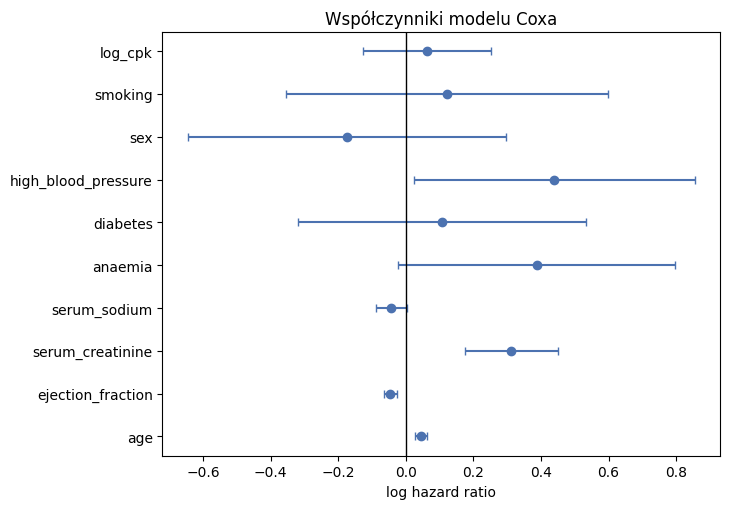

In [2]:
cph = CoxPHFitter(penalizer=0.01)
cph.fit(cox_df, duration_col="duration", event_col="event")
cox_summary = cph.summary[["coef", "exp(coef)", "se(coef)", "p", "coef lower 95%", "coef upper 95%"]].round(4)
show("Wyniki modelu Coxa", cox_summary)

fig, ax = plt.subplots(figsize=(7.4, 5.2))
coefs = cox_summary["coef"]
lower = cox_summary["coef lower 95%"]
upper = cox_summary["coef upper 95%"]
y = np.arange(len(coefs))
ax.errorbar(coefs, y, xerr=[coefs - lower, upper - coefs], fmt="o", color="#4C72B0", ecolor="#4C72B0", capsize=3)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(coefs.index)
ax.set(title="Współczynniki modelu Coxa", xlabel="log hazard ratio")
plt.tight_layout()


## Test proporcjonalności hazardów


In [3]:
ph = proportional_hazard_test(cph, cox_df, time_transform="rank")
ph_table = ph.summary[["test_statistic", "p"]].sort_values("p").round(4)
show("Test proporcjonalności hazardów", ph_table)



Test proporcjonalności hazardów
-------------------------------
                     test_statistic       p
ejection_fraction            5.6803  0.0172
log_cpk                      3.5287  0.0603
serum_creatinine             3.4625  0.0628
serum_sodium                 1.6642  0.1970
sex                          0.4778  0.4894
smoking                      0.1621  0.6873
age                          0.1047  0.7463
high_blood_pressure          0.0888  0.7657
diabetes                     0.0033  0.9545
anaemia                      0.0000  0.9986


## Reszty Schoenfelda



Fragment macierzy reszt Schoenfelda
-----------------------------------
covariate      age  ejection_fraction  serum_creatinine  serum_sodium  anaemia  diabetes  high_blood_pressure     sex  smoking  log_cpk
0           6.0009           -12.7668           -0.8348       -4.5004  -0.5964   -0.3500               0.4638  0.3003  -0.3839   0.8233
1         -13.9193             5.0633           -1.6459        1.4397  -0.6043   -0.3547              -0.5301  0.3043  -0.3891   3.4359
2          -3.9531           -12.9563           -1.4501       -5.5639  -0.6054   -0.3558              -0.5317  0.3052   0.6110  -0.5409
3         -18.9531           -12.9563           -0.8501        2.4361   0.3946   -0.3558              -0.5317  0.3052  -0.3890  -0.8128
4          -3.9546           -13.0845           -0.0601      -18.7000   0.3969    0.6447              -0.5363 -0.6960  -0.3876  -0.4625


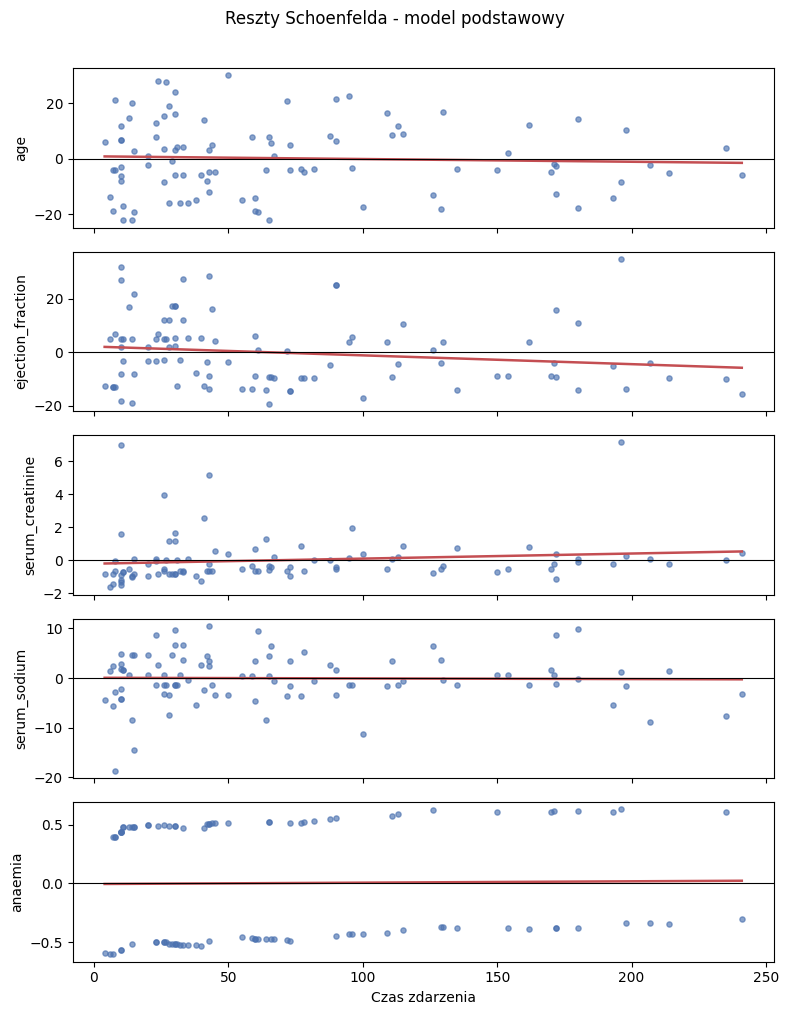

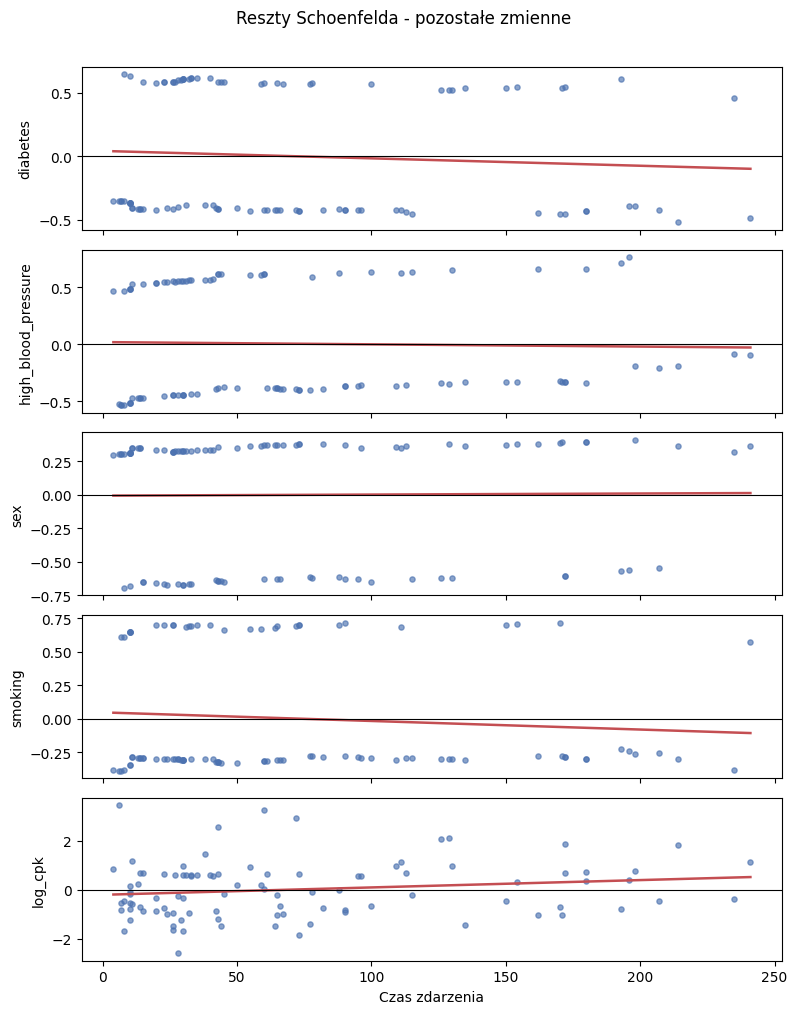

In [4]:
schoenfeld = cph.compute_residuals(cox_df, kind="schoenfeld")
event_times = cox_df.loc[schoenfeld.index, "duration"]
show("Fragment macierzy reszt Schoenfelda", schoenfeld.head().round(4))

plot_vars = cox_vars[:5]
fig, axes = plt.subplots(len(plot_vars), 1, figsize=(8, 10), sharex=True)
for ax, var in zip(axes, plot_vars):
    ax.scatter(event_times, schoenfeld[var], s=14, alpha=0.65, color="#4C72B0")
    z = np.polyfit(event_times, schoenfeld[var], 1)
    ax.plot(np.sort(event_times), np.polyval(z, np.sort(event_times)), color="#C44E52", lw=1.8)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel(var)
axes[-1].set_xlabel("Czas zdarzenia")
fig.suptitle("Reszty Schoenfelda - model podstawowy", y=1.01)
plt.tight_layout()

remaining = cox_vars[5:]
fig, axes = plt.subplots(len(remaining), 1, figsize=(8, 10), sharex=True)
for ax, var in zip(axes, remaining):
    ax.scatter(event_times, schoenfeld[var], s=14, alpha=0.65, color="#4C72B0")
    z = np.polyfit(event_times, schoenfeld[var], 1)
    ax.plot(np.sort(event_times), np.polyval(z, np.sort(event_times)), color="#C44E52", lw=1.8)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel(var)
axes[-1].set_xlabel("Czas zdarzenia")
fig.suptitle("Reszty Schoenfelda - pozostałe zmienne", y=1.01)
plt.tight_layout()


## Model Coxa z interakcją czasową dla frakcji wyrzutowej


In [5]:
cox_td = cox_df.copy()
cox_td["ef_log_time"] = cox_td["ejection_fraction"] * np.log1p(cox_td["duration"])
cox_td_vars = cox_vars + ["ef_log_time"]
cph_td = CoxPHFitter(penalizer=0.01)
cph_td.fit(cox_td[["duration", "event"] + cox_td_vars], duration_col="duration", event_col="event")
td_summary = cph_td.summary.loc[["ejection_fraction", "ef_log_time"], ["coef", "exp(coef)", "se(coef)", "p"]].round(4)
show("Model Coxa z interakcją czasową", td_summary)

compare = pd.DataFrame({
    "model": ["Cox podstawowy", "Cox z interakcją czasową"],
    "logLik": [cph.log_likelihood_, cph_td.log_likelihood_],
    "partial_AIC": [cph.AIC_partial_, cph_td.AIC_partial_],
    "liczba_parametrów": [len(cph.params_), len(cph_td.params_)],
}).round(3)
show("Porównanie modelu podstawowego i modelu z interakcją", compare)

ph_td = proportional_hazard_test(cph_td, cox_td[["duration", "event"] + cox_td_vars], time_transform="rank")
show("Test PH po dodaniu interakcji czasowej", ph_td.summary[["test_statistic", "p"]].sort_values("p").round(4))



Model Coxa z interakcją czasową
-------------------------------
                     coef  exp(coef)  se(coef)    p
covariate                                          
ejection_fraction  0.2104     1.2342    0.0190  0.0
ef_log_time       -0.0630     0.9390    0.0046  0.0

Porównanie modelu podstawowego i modelu z interakcją
----------------------------------------------------
                      model   logLik  partial_AIC  liczba_parametrów
0            Cox podstawowy -471.283      962.566                 10
1  Cox z interakcją czasową -363.175      748.349                 11

Test PH po dodaniu interakcji czasowej
--------------------------------------
                     test_statistic       p
serum_creatinine             6.6064  0.0102
ef_log_time                  3.1346  0.0766
anaemia                      1.3662  0.2425
log_cpk                      0.6964  0.4040
sex                          0.4309  0.5115
age                          0.2824  0.5951
serum_sodium              

## Obserwacje wpływowe


In [6]:
delta_beta = cph.compute_residuals(cox_df, kind="delta_beta")
influence = delta_beta.abs().sum(axis=1).sort_values(ascending=False)
top_idx = influence.head(8).index
show("Fragment macierzy delta-beta", delta_beta.head().round(5))
show("Ranking obserwacji wpływowych", influence.head(10).round(5))
influential_cases = df.loc[top_idx, ["time", "DEATH_EVENT", "age", "ejection_fraction", "serum_creatinine", "serum_sodium"]]
show("Wartości zmiennych dla najbardziej wpływowych obserwacji", influential_cases.round(3))



Fragment macierzy delta-beta
----------------------------
covariate      age  ejection_fraction  serum_creatinine  serum_sodium  anaemia  diabetes  high_blood_pressure      sex  smoking  log_cpk
0         -0.01596           -0.00784           0.00526      -0.00042  0.00964  -0.09243              0.02107  0.01659 -0.05024  0.01411
1         -0.03736            0.01377          -0.00088       0.00484 -0.01007  -0.17931              0.01109  0.14212 -0.08155  0.03888
2         -0.02589           -0.00696           0.00190      -0.00236  0.02109  -0.14666              0.00308  0.03248 -0.04896  0.00468
3         -0.04097           -0.00760           0.02195       0.01704  0.02532  -0.19547             -0.00678  0.09714 -0.12028  0.00555
4         -0.02539           -0.00487          -0.01511      -0.03185  0.07912  -0.16486              0.01668 -0.00400 -0.04573  0.01270

Ranking obserwacji wpływowych
-----------------------------
55     1.40233
48     1.14839
220    0.82257
19     0.7323

## Predykcje funkcji przeżycia z modelu Coxa


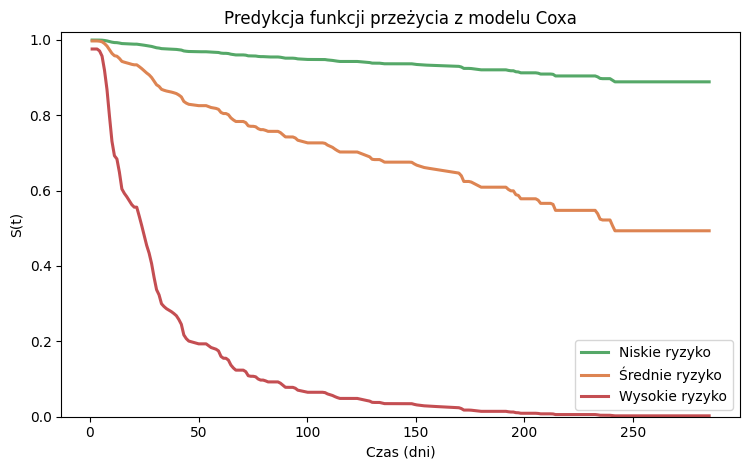

In [7]:
profiles = pd.DataFrame({
    "age": [50, 65, 75],
    "ejection_fraction": [45, 35, 20],
    "serum_creatinine": [1.0, 1.4, 2.2],
    "serum_sodium": [140, 137, 132],
    "anaemia": [0, 0, 1],
    "diabetes": [0, 1, 1],
    "high_blood_pressure": [0, 1, 1],
    "sex": [0, 1, 1],
    "smoking": [0, 0, 1],
    "log_cpk": [df["log_cpk"].quantile(0.25), df["log_cpk"].median(), df["log_cpk"].quantile(0.75)],
}, index=["Niskie ryzyko", "Średnie ryzyko", "Wysokie ryzyko"])[cox_vars]
surv = cph.predict_survival_function(profiles, times=np.linspace(1, df["duration"].max(), 250))
fig, ax = plt.subplots(figsize=(7.6, 4.8))
for label, color in zip(profiles.index, ["#55A868", "#DD8452", "#C44E52"]):
    ax.plot(surv.index, surv[label], lw=2.2, label=label, color=color)
ax.set(title="Predykcja funkcji przeżycia z modelu Coxa", xlabel="Czas (dni)", ylabel="S(t)", ylim=(0, 1.02))
ax.legend()
plt.tight_layout()


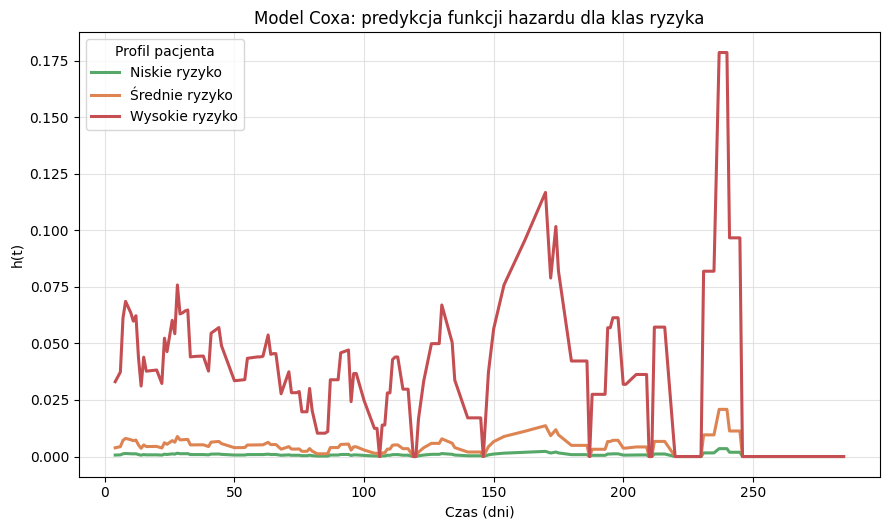


Predykcja hazardu z modelu Coxa: pierwsze warto?ci
--------------------------------------------------
      Niskie ryzyko  Średnie ryzyko  Wysokie ryzyko
4.0        0.000479        0.002864        0.024536
6.0        0.000485        0.002903        0.024862
7.0        0.000971        0.005812        0.049779
8.0        0.000979        0.005857        0.050170
10.0       0.003052        0.018264        0.156443


In [11]:
# Predykcja funkcji hazardu z modelu Coxa dla trzech profili ryzyka.

baseline_hazard = cph.baseline_hazard_.iloc[:, 0]
partial_hazards = cph.predict_partial_hazard(profiles)
hazard_profiles = pd.DataFrame(index=baseline_hazard.index)
for label in profiles.index:
    hazard_profiles[label] = baseline_hazard * float(partial_hazards.loc[label])

hazard_plot = hazard_profiles.rolling(window=5, min_periods=1, center=True).mean()
fig, ax = plt.subplots(figsize=(9, 5.4))
for label, color in zip(profiles.index, ["#55A868", "#DD8452", "#C44E52"]):
    ax.plot(hazard_plot.index, hazard_plot[label], lw=2.2, label=label, color=color)
ax.set(
    title="Model Coxa: predykcja funkcji hazardu dla klas ryzyka",
    xlabel="Czas (dni)",
    ylabel="h(t)",
)
ax.grid(True, color="#dddddd", linewidth=0.8, alpha=0.8)
ax.legend(title="Profil pacjenta")
fig.tight_layout()
plt.show()
show("Predykcja hazardu z modelu Coxa: pierwsze warto?ci", hazard_profiles.head().round(6))


## Wnioski kontrolne

            Notebook odtwarza wyniki semiparametryczne użyte w prezentacji i pokazuje sposób obliczenia diagnostyki PH, reszt Schoenfelda, obserwacji wpływowych oraz predykcji profili.
